In [13]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
from clean import clean_data
import models

In [4]:
print(sys.executable)

/opt/anaconda3/envs/stat214/bin/python


# PRE-CLEANING Exploration

## Basic Structural Checks

### Shape of dataset

In [8]:
original_data = pd.read_csv("../data/TBI PUD 10-08-2013.csv")
print(original_data.shape)

(43399, 125)


We can see below that the column names are incomprehensible to someone without medical expertise. In order for anyone to understand the report we will be changing the column names that are self explanatory.

In [5]:
print(original_data.columns)

Index(['PatNum', 'EmplType', 'Certification', 'InjuryMech',
       'High_impact_InjSev', 'Amnesia_verb', 'LOCSeparate', 'LocLen', 'Seiz',
       'SeizOccur',
       ...
       'Finding20', 'Finding21', 'Finding22', 'Finding23', 'DeathTBI',
       'HospHead', 'HospHeadPosCT', 'Intub24Head', 'Neurosurgery',
       'PosIntFinal'],
      dtype='str', length=125)


### Checking if any rows have null Patient Number and duplicate Patient Number

In [31]:
(original_data["PatNum"].isna()).sum()

np.int64(0)

In [86]:
original_data["PatNum"].duplicated().sum()

np.int64(0)

### Checking if all "Ages in years" are less than 18

In [5]:
original_data["AgeinYears"].unique()

array([16,  5, 14,  1,  3,  4, 12,  2,  0,  7,  9, 11, 10, 15, 17,  6, 13,
        8])

In [84]:
original_data["AgeInMonth"].unique()

array([197,  64, 170,  13,  14,  46,  51, 145,  27,  29,   1,  87,  17,
         8, 147, 115,  94,   4,  26,  62, 143,  28, 131,  60,  12, 175,
       187,  85, 188,  47,  41,  93, 180, 215,  79, 163,   9,  80,  24,
        45, 209, 211, 208,  25,   7,  77, 182,  88,  82,   5,  56,  16,
       158, 214,  90,  15, 114, 129,  99,  32,  34,  23, 194,  31, 173,
        59, 168, 205, 179,  21, 183, 165, 171,   3,  10, 201,  39,  65,
       102, 137,  19,  30, 146, 110, 192, 126, 155, 189, 184, 124, 154,
        55,  58, 200,  83, 141, 101,  89, 212,  70, 206, 113, 159,  22,
       135,   2, 112, 140, 118,  52,  20, 178, 120, 193,  68,  37,  96,
        36, 195, 108, 122, 185,   6, 167, 119, 109,  49,  57, 196, 134,
       174, 116,  42, 151,  75,  73,  48,  76, 162,  74, 107, 139, 198,
        86,  66,  18, 148,  50, 202, 156, 132,  97,  11,  35,  44, 186,
        61, 117, 191, 157,   0, 133, 169, 204, 100,  54, 130, 190,  38,
        78,  84,  92, 128,  95, 105,  71, 164, 213,  53,  67, 17

### Checking if any ages in months are greater than or equal to 216 months(18 years)

In [94]:
(original_data["AgeInMonth"]>=216).sum()

np.int64(0)

### Checking if "Age in months" match "Age in years"

In [5]:
df = original_data
df["AgeCheck"] = (df["AgeInMonth"]//12 - df["AgeinYears"]).abs()
mismatches = df.loc[df["AgeCheck"]>0]
mismatches.shape

/var/folders/14/jb6nx3p121vbc2c7ykn2pbdm0000gn/T/ipykernel_37305/3709321644.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["AgeCheck"] = (df["AgeInMonth"]//12 - df["AgeinYears"]).abs()


(0, 126)

### Checking GCSGroup
We are going to be separating patients with score 14-15 from those below 14.

In [18]:
(df["GCSGroup"] == 1).sum()

np.int64(969)

### Missing values in PosIntFinal column

Here, we can see that there are 18 rows where PosIntFinal has null values. These are instances where outcomes are unknown and ciTBI cannot be determined. Such patients cannot be included in the study. So we will be removing them.

In [22]:
rows = df.loc[df["PosIntFinal"].isna(), ["PatNum","EDDisposition"]]
rows

,PatNum,EDDisposition
75,76,5.0
781,782,3.0
947,948,4.0
6112,6113,6.0
9541,9542,3.0
10514,10515,4.0
10721,10722,6.0
15233,15234,6.0
23581,23582,6.0
24073,24074,6.0


In the above rows we can see that these 18 patients were either transferred to general admit, or kept for less than 24h or they were transferred to other hospitals.

### Checking how many rows have NaN values column-wise

In [23]:
#Note: we have already dealt with null values in PosIntFinal above
df.isna().sum()[df.isna().sum() > 0]

EmplType                 18
InjuryMech              301
High_impact_InjSev      334
Amnesia_verb           2296
LOCSeparate            1892
LocLen                 2556
Seiz                    912
SeizOccur                71
SeizLen                 117
ActNorm                3335
HA_verb                 652
HASeverity             1044
HAStart                1332
Vomit                   443
VomitNbr                297
VomitStart              413
VomitLast               992
Dizzy                 15972
Intubated               325
Paralyzed               336
Sedated                 339
GCSEye                 1288
GCSVerbal              1298
GCSMotor               1310
AMS                     316
SFxPalp                 104
SFxPalpDepress           55
FontBulg                167
SFxBas                  445
Hema                    305
HemaLoc                 211
HemaSize                742
Clav                    137
NeuroD                  660
OSI                     195
Drugs               

### EmplType Column

In [27]:
df["EmplType"].unique()

array([ 3.,  5.,  4.,  1.,  2., nan])

### Injury Mechanism
This column contains 301 rows have NaN values

In [28]:
df["InjuryMech"].unique()

array([11.,  8.,  5.,  6., 12., nan,  7., 10., 90.,  2.,  1.,  4.,  9.,
        3.])

Below we are trying to understand if there is a particular reason for which Injury Mechanism and its Severity is missing

We can see below that there are 33 columns where Injury Mechanism has values but the corresponding column "High_impact_InjSev" has missing values. This needs to be updated.

In [35]:
rows = df[df["InjuryMech"].notna() & df["High_impact_InjSev"].isna()]
rows.shape

(33, 127)

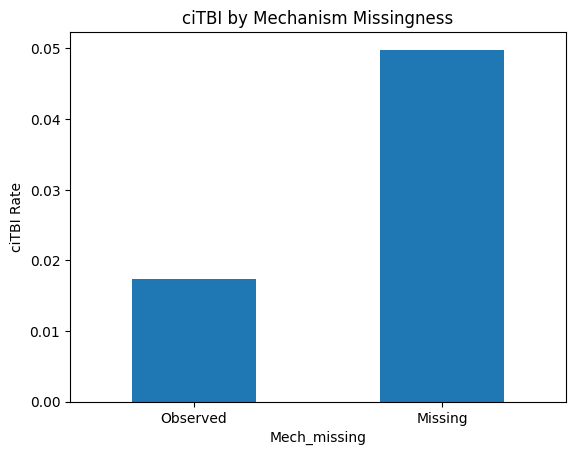

In [107]:
df["Mech_missing"] = df["InjuryMech"].isna().astype(int) & df["High_impact_InjSev"].isna().astype(int)
df.groupby("Mech_missing")["PosIntFinal"].mean().plot(kind="bar")
plt.xticks([0,1], ["Observed", "Missing"], rotation=0)
plt.ylabel("ciTBI Rate")
plt.title("ciTBI by Mechanism Missingness")
plt.show()

One explanation for missing data in Injury Mechanism and Severity for injury mechanism could do with severity of such cases. From above we can understand that there is a high probability of ciTBI in cases of missing mechanism.

### DeathTBI, HospHead, HospHeadPosCT, Intub24Head, Neurosurgery, PosIntFinal

In [122]:
df.loc[df["DeathTBI"].isna(), ["DeathTBI","HospHead", "HospHeadPosCT", "Intub24Head", "Neurosurgery", "PosIntFinal"]]

,DeathTBI,HospHead,HospHeadPosCT,Intub24Head,Neurosurgery,PosIntFinal
75,NaN,NaN,0,0.0,0.0,NaN
781,NaN,0.0,0,0.0,0.0,NaN
8196,NaN,0.0,0,0.0,0.0,0.0
28310,NaN,0.0,0,NaN,0.0,NaN
33429,NaN,0.0,0,0.0,NaN,0.0
35950,NaN,0.0,0,0.0,0.0,0.0
37293,NaN,0.0,0,0.0,0.0,0.0
38210,NaN,0.0,0,0.0,0.0,0.0


In [118]:
df.loc[df["HospHead"].isna(), ["DeathTBI","HospHead", "HospHeadPosCT", "Intub24Head", "Neurosurgery", "PosIntFinal"]]

,DeathTBI,HospHead,HospHeadPosCT,Intub24Head,Neurosurgery,PosIntFinal
75,NaN,NaN,0,0.0,0.0,NaN
9541,0.0,NaN,0,0.0,0.0,NaN
42815,0.0,NaN,0,0.0,0.0,0.0


In [120]:
df.loc[df["Intub24Head"].isna(), ["DeathTBI","HospHead", "HospHeadPosCT", "Intub24Head", "Neurosurgery", "PosIntFinal"]]

,DeathTBI,HospHead,HospHeadPosCT,Intub24Head,Neurosurgery,PosIntFinal
22642,0.0,1.0,1,NaN,1.0,1.0
28310,NaN,0.0,0,NaN,0.0,NaN
32908,0.0,0.0,0,NaN,0.0,0.0
41802,0.0,0.0,0,NaN,0.0,0.0


In [123]:
df.loc[df["Neurosurgery"].isna(), ["DeathTBI","HospHead", "HospHeadPosCT", "Intub24Head", "Neurosurgery", "PosIntFinal"]]

,DeathTBI,HospHead,HospHeadPosCT,Intub24Head,Neurosurgery,PosIntFinal
33429,NaN,0.0,0,0.0,NaN,0.0


### Loss of Consciousness and length of LOC

In [138]:
df[df["LOCSeparate"].isna() & (df["LocLen"].isna())]

,PatNum,EmplType,Certification,InjuryMech,High_impact_InjSev,Amnesia_verb,LOCSeparate,LocLen,Seiz,SeizOccur,...,Finding23,DeathTBI,HospHead,HospHeadPosCT,Intub24Head,Neurosurgery,PosIntFinal,AgeCheck,Mech_missing,LOC_Missing


In [136]:
df[df["LOCSeparate"].isna() & (df["LocLen"]!=92)]

,PatNum,EmplType,Certification,InjuryMech,High_impact_InjSev,Amnesia_verb,LOCSeparate,LocLen,Seiz,SeizOccur,...,Finding23,DeathTBI,HospHead,HospHeadPosCT,Intub24Head,Neurosurgery,PosIntFinal,AgeCheck,Mech_missing,LOC_Missing


In [128]:
df["LOCSeparate"].isna().mean()

np.float64(0.04359547455010484)

In [130]:
df.groupby(df["LOCSeparate"].isna())["PosIntFinal"].mean()

LOCSeparate
False    0.015306
True     0.067653
Name: PosIntFinal, dtype: float64

/var/folders/14/jb6nx3p121vbc2c7ykn2pbdm0000gn/T/ipykernel_28933/1425807156.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["LOC_Missing"] = df["LOCSeparate"].isna().astype(int)


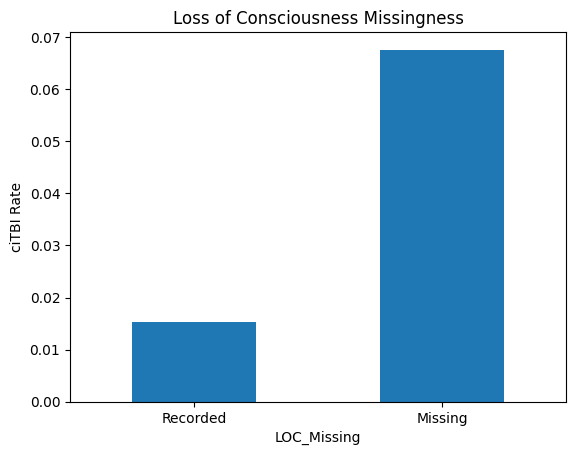

In [132]:
df["LOC_Missing"] = df["LOCSeparate"].isna().astype(int)
df.groupby("LOC_Missing")["PosIntFinal"].mean().plot(kind="bar")
plt.xticks([0,1], ["Recorded", "Missing"], rotation=0)
plt.ylabel("ciTBI Rate")
plt.title("Loss of Consciousness Missingness")
plt.show()

In [131]:
df.groupby(df["LOCSeparate"].isna())[["Sedated","Intubated","ActNorm"]].mean()

,Sedated,Intubated,ActNorm
LOCSeparate,,,
False,0.004152,0.004369,0.837831
True,0.022885,0.020224,0.637525


/var/folders/14/jb6nx3p121vbc2c7ykn2pbdm0000gn/T/ipykernel_28933/1193046362.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.assign(LOC_status=df["LOCSeparate"].isna()


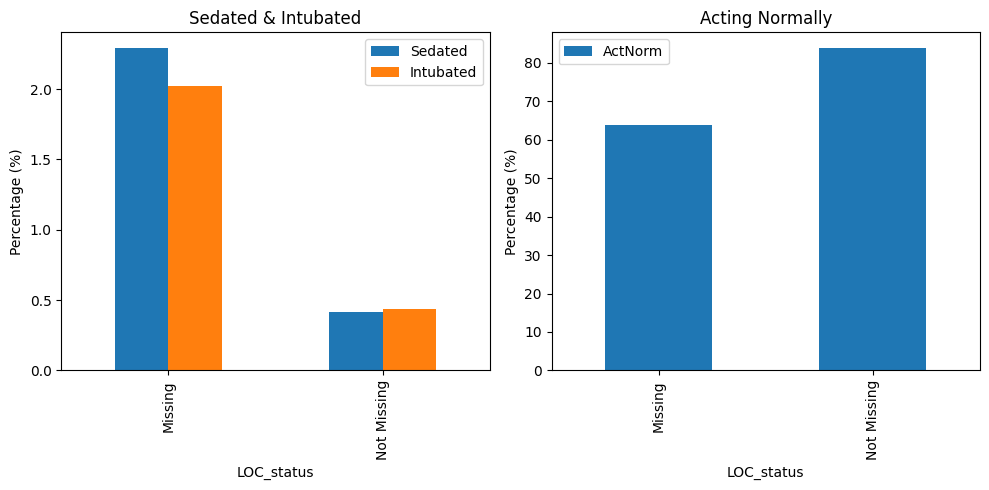

In [140]:
grouped = (
    df.assign(LOC_status=df["LOCSeparate"].isna()
              .map({True: "Missing", False: "Not Missing"}))
      .groupby("LOC_status")[["Sedated","Intubated","ActNorm"]]
      .mean()
      .mul(100)
)

fig, axes = plt.subplots(1, 2, figsize=(10,5))

grouped[["Sedated","Intubated"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Sedated & Intubated")
axes[0].set_ylabel("Percentage (%)")

grouped[["ActNorm"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("Acting Normally")
axes[1].set_ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

In [134]:
df[
    df["LocLen"].isna()
].groupby("LOCSeparate").size()


LOCSeparate
1.0    1536
2.0    1020
dtype: int64

Seiz                    
SeizOccur                
SeizLen 

/var/folders/14/jb6nx3p121vbc2c7ykn2pbdm0000gn/T/ipykernel_37305/357706915.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Seizure_Missing"] = df["Seiz"].isna().astype(int)


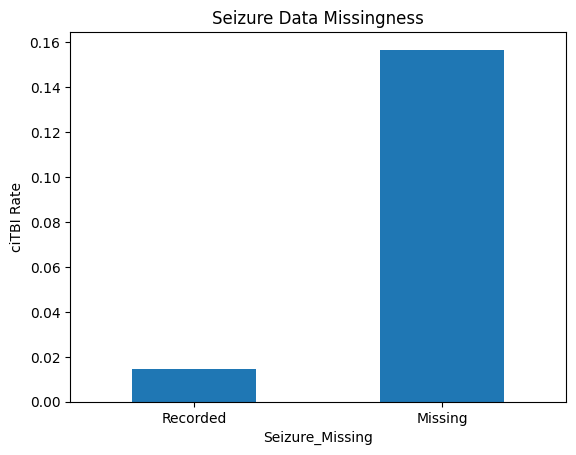

In [15]:
df["Seizure_Missing"] = df["Seiz"].isna().astype(int)
df.groupby("Seizure_Missing")["PosIntFinal"].mean().plot(kind="bar")
plt.xticks([0,1], ["Recorded", "Missing"], rotation=0)
plt.ylabel("ciTBI Rate")
plt.title("Seizure Data Missingness")
plt.show()

In [52]:
pd.crosstab(df["SeizLen"], df["SeizOccur"])

SeizOccur,1.0,2.0,3.0,92.0
SeizLen,,,,
1.0,132,99,22,0
2.0,79,71,21,0
3.0,8,10,9,0
4.0,5,4,8,0
92.0,0,0,0,42796


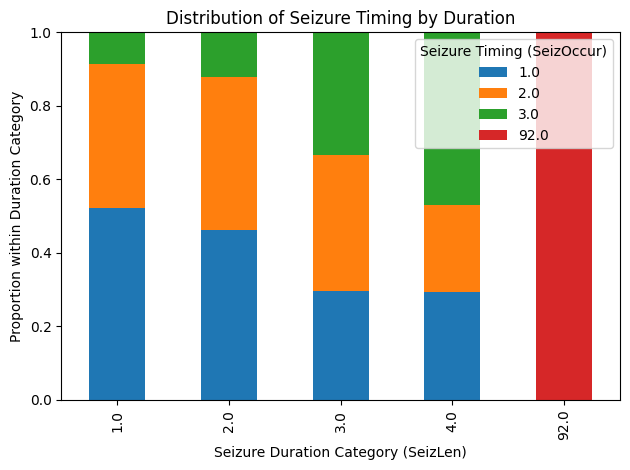

SeizOccur,1.0,2.0,3.0,92.0
SeizLen,,,,
1.0,0.521739,0.391304,0.086957,0.0
2.0,0.461988,0.415205,0.122807,0.0
3.0,0.296296,0.370370,0.333333,0.0
4.0,0.294118,0.235294,0.470588,0.0
92.0,0.000000,0.000000,0.000000,1.0


In [54]:
ct = pd.crosstab(df["SeizLen"], df["SeizOccur"])
#Normalize within each duration category
ct_norm = ct.div(ct.sum(axis=1), axis=0)

ct_norm.plot(kind="bar", stacked=True)

plt.xlabel("Seizure Duration Category (SeizLen)")
plt.ylabel("Proportion within Duration Category")
plt.title("Distribution of Seizure Timing by Duration")
plt.legend(title="Seizure Timing (SeizOccur)")
plt.tight_layout()
plt.show()

ct_norm

### Is amnesia, headache, and dizziness recorded for children < 2 years? 

In [68]:
rows = df.loc[(df["Amnesia_verb"]!= 91.) & (df["AgeinYears"]<2), ["AgeinYears", "Amnesia_verb", "HA_verb", "Dizzy","Paralyzed", "Sedated", "Intubated","ActNorm","AMSSlow","NeuroD"]]
rows.shape

(1178, 10)

In [69]:
rows = df.loc[(df["HA_verb"]!= 91.) & (df["AgeinYears"]<2), ["AgeinYears", "Amnesia_verb", "HA_verb", "Dizzy","Paralyzed", "Sedated", "Intubated","ActNorm","AMSSlow","NeuroD"]]
rows.shape

(1114, 10)

In [76]:
rows = df.loc[(df["Dizzy"]!= 91.) & (df["AgeinYears"]<2), ["AgeinYears", "Amnesia_verb", "HA_verb", "Dizzy","Paralyzed", "Sedated", "Intubated","ActNorm","AMSSlow","NeuroD"]]
rows.shape

(10904, 10)

### We can see a lot of rows of NAN values in these columns. We need to check why 

In [64]:
rows = df.loc[(df["Amnesia_verb"].isna()) & (df["AgeinYears"]>=2), ["AgeinYears", "Amnesia_verb", "HA_verb", "Dizzy","Paralyzed", "Sedated", "Intubated","ActNorm","AMSSlow","NeuroD"]]
rows

,AgeinYears,Amnesia_verb,HA_verb,Dizzy,Paralyzed,Sedated,Intubated,ActNorm,AMSSlow,NeuroD
2,14,NaN,NaN,NaN,1.0,1.0,1.0,0.0,0,NaN
36,2,NaN,0.0,0.0,0.0,0.0,0.0,1.0,92,0.0
61,6,NaN,1.0,1.0,0.0,0.0,0.0,0.0,92,0.0
71,9,NaN,0.0,0.0,0.0,0.0,0.0,1.0,92,0.0
75,8,NaN,91.0,NaN,0.0,0.0,0.0,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...
43275,2,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0,0.0
43298,13,NaN,0.0,0.0,0.0,0.0,0.0,1.0,92,0.0
43299,10,NaN,NaN,NaN,0.0,0.0,0.0,NaN,0,0.0
43335,4,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0,0.0


### Act Normal

In [135]:
df.groupby(
    df["ActNorm"].isna()
)[["AMS", "Sedated", "Intubated", "Paralyzed", "AgeinYears"]].mean()


,AMS,Sedated,Intubated,Paralyzed,AgeinYears
ActNorm,,,,,
False,0.121596,0.000613,0.000077,0.000077,6.359260
True,0.246441,0.002694,0.000336,0.000336,9.263473


In [136]:
df.groupby(
    df["ActNorm"].isna()
)["PosIntFinal"].mean()


ActNorm
False    0.006928
True     0.034265
Name: PosIntFinal, dtype: float64

### Vomit Symptoms

In [139]:
vomit_cols = ["Vomit", "VomitNbr", "VomitStart", "VomitLast"]
df[vomit_cols].isna().sum()

Vomit         443
VomitNbr      297
VomitStart    413
VomitLast     992
dtype: int64

In [142]:
df.loc[
    df["Vomit"].isna(),
    vomit_cols
]

,Vomit,VomitNbr,VomitStart,VomitLast
2,NaN,92.0,92.0,92.0
167,NaN,92.0,92.0,92.0
312,NaN,92.0,92.0,92.0
351,NaN,92.0,92.0,92.0
413,NaN,92.0,92.0,92.0
...,...,...,...,...
43005,NaN,92.0,92.0,92.0
43063,NaN,92.0,92.0,92.0
43071,NaN,92.0,92.0,92.0
43104,NaN,92.0,92.0,92.0


In [147]:
df.loc[
    (df["VomitNbr"].isna()) &
    (df["Vomit"] == 1),
    vomit_cols
]
df["Vomit"].isna().sum()

np.int64(443)

In [146]:
df.loc[
    (df["VomitNbr"].isna()) &
    (df["Vomit"] == 1),
    vomit_cols
]
(
    (df["VomitNbr"].isna()) &
    (df["Vomit"] == 1)
).sum()


np.int64(253)

In [150]:
df.loc[
    (df["VomitStart"].isna()) &
    (df["Vomit"] == 1),
    vomit_cols
]

,Vomit,VomitNbr,VomitStart,VomitLast
471,1.0,1.0,NaN,NaN
477,1.0,1.0,NaN,NaN
481,1.0,NaN,NaN,1.0
570,1.0,NaN,NaN,NaN
645,1.0,1.0,NaN,NaN
...,...,...,...,...
42784,1.0,1.0,NaN,NaN
43026,1.0,NaN,NaN,NaN
43045,1.0,3.0,NaN,NaN
43140,1.0,3.0,NaN,2.0


In [151]:
df.loc[
    (df["VomitLast"].isna()) &
    (df["Vomit"] == 1),
    vomit_cols
]

,Vomit,VomitNbr,VomitStart,VomitLast
24,1.0,1.0,3.0,NaN
59,1.0,1.0,2.0,NaN
64,1.0,2.0,2.0,NaN
161,1.0,NaN,4.0,NaN
340,1.0,NaN,2.0,NaN
...,...,...,...,...
43197,1.0,1.0,2.0,NaN
43214,1.0,2.0,3.0,NaN
43221,1.0,2.0,3.0,NaN
43224,1.0,1.0,2.0,NaN


In [152]:
df.loc[
    (df["Vomit"] == 0) &
    (
        df["VomitNbr"].isna() |
        df["VomitStart"].isna() |
        df["VomitLast"].isna()
    ),
    vomit_cols
]

,Vomit,VomitNbr,VomitStart,VomitLast


In [153]:
df.loc[
    (df["Vomit"] == 1) &
    df[["VomitNbr","VomitStart","VomitLast"]].isna().all(axis=1),
    vomit_cols
]

,Vomit,VomitNbr,VomitStart,VomitLast
570,1.0,NaN,NaN,NaN
708,1.0,NaN,NaN,NaN
778,1.0,NaN,NaN,NaN
1465,1.0,NaN,NaN,NaN
2174,1.0,NaN,NaN,NaN
2569,1.0,NaN,NaN,NaN
7562,1.0,NaN,NaN,NaN
8645,1.0,NaN,NaN,NaN
9983,1.0,NaN,NaN,NaN
11735,1.0,NaN,NaN,NaN


In [154]:
summary = pd.DataFrame({
    "Vomit_is_NaN": df["Vomit"].isna().sum(),
    "VomitNbr_missing_given_vomit1": (
        (df["VomitNbr"].isna()) &
        (df["Vomit"] == 1)
    ).sum(),
    "VomitStart_missing_given_vomit1": (
        (df["VomitStart"].isna()) &
        (df["Vomit"] == 1)
    ).sum(),
    "VomitLast_missing_given_vomit1": (
        (df["VomitLast"].isna()) &
        (df["Vomit"] == 1)
    ).sum(),
}, index=["Count"])

summary


,Vomit_is_NaN,VomitNbr_missing_given_vomit1,VomitStart_missing_given_vomit1,VomitLast_missing_given_vomit1
Count,443,297,413,992


In [160]:
#SFxPalp             101
#SFxPalpDepress       31
#FontBulg            159
#SFxBas              421
df.loc[df["SFxPalp"]==1.0, ["SFxPalp","SFxPalpDepress","FontBulg","SFxBas","Clav"]]

,SFxPalp,SFxPalpDepress,FontBulg,SFxBas,Clav
2,1.0,1.0,0.0,1.0,1.0
307,1.0,0.0,0.0,0.0,1.0
311,1.0,0.0,0.0,0.0,1.0
353,1.0,1.0,0.0,0.0,1.0
421,1.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...
42177,1.0,0.0,0.0,1.0,0.0
42209,1.0,1.0,0.0,0.0,1.0
42268,1.0,0.0,0.0,0.0,1.0
42920,1.0,0.0,0.0,0.0,1.0


# Data Cleaning

In [5]:
raw_df = pd.read_csv("../data/TBI PUD 10-08-2013.csv")
clean_df = clean_data(raw_df)

# Findings

Finding 1

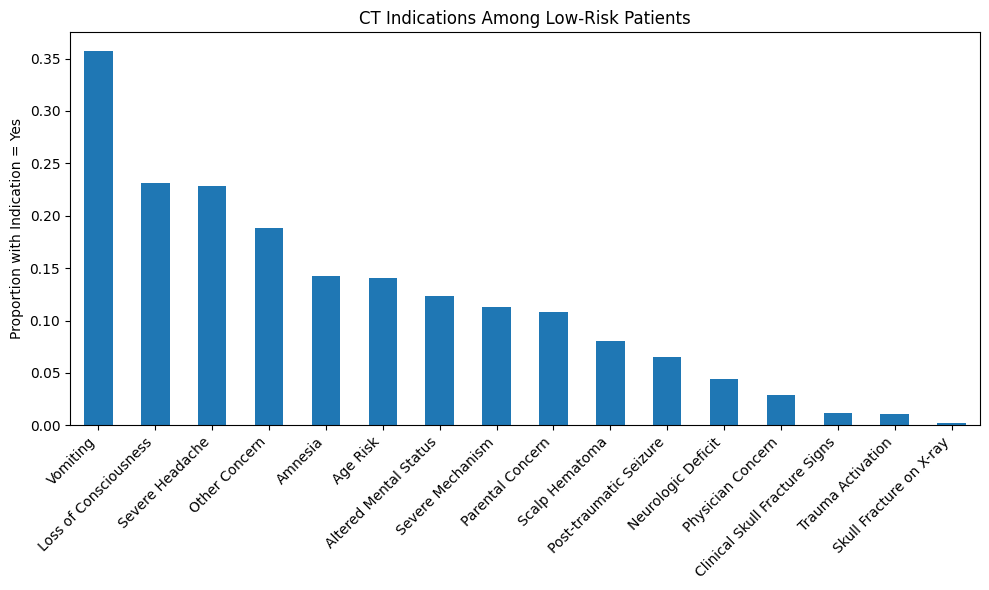

In [187]:
lowrisk_ct = clean_df.loc[
    (clean_df["High_impact_InjSev"] == 1) &
    (clean_df["Clav"] == 0) &
    (clean_df["CTDone"] == 1)
]

ind_cols = [
    "IndAge","IndAmnesia","IndAMS","IndClinSFx","IndHA",
    "IndHema","IndLOC","IndMech","IndNeuroD","IndRqstMD",
    "IndRqstParent","IndRqstTrauma","IndSeiz","IndVomit",
    "IndXraySFx","IndOth"
]

label_map = {
    "IndAge": "Age Risk",
    "IndAmnesia": "Amnesia",
    "IndAMS": "Altered Mental Status",
    "IndClinSFx": "Clinical Skull Fracture Signs",
    "IndHA": "Severe Headache",
    "IndHema": "Scalp Hematoma",
    "IndLOC": "Loss of Consciousness",
    "IndMech": "Severe Mechanism",
    "IndNeuroD": "Neurologic Deficit",
    "IndRqstMD": "Physician Concern",
    "IndRqstParent": "Parental Concern",
    "IndRqstTrauma": "Trauma Activation",
    "IndSeiz": "Post-traumatic Seizure",
    "IndVomit": "Vomiting",
    "IndXraySFx": "Skull Fracture on X-ray",
    "IndOth": "Other Concern"
}

ind_rates = (lowrisk_ct[ind_cols] == 1).mean().sort_values(ascending=False)
ind_rates.index = ind_rates.index.map(lambda x: label_map.get(x, x))
plt.figure(figsize=(10, 6))
ind_rates.plot(kind="bar")
plt.ylabel("Proportion with Indication = Yes")
plt.title("CT Indications Among Low-Risk Patients")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

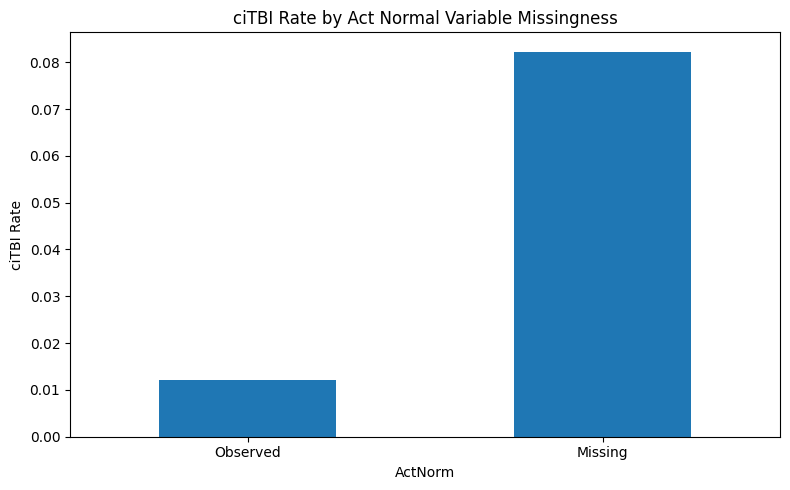

In [192]:
plt.figure(figsize=(8,5))

actnorm_missing = df["ActNorm"].isna().astype(int)
ci_rate = df.groupby(actnorm_missing)["PosIntFinal"].mean()

ci_rate.plot(kind="bar")
plt.xticks([0,1], ["Observed", "Missing"], rotation=0)
plt.ylabel("ciTBI Rate")
plt.title("ciTBI Rate by Act Normal Variable Missingness")
plt.tight_layout()
plt.show()

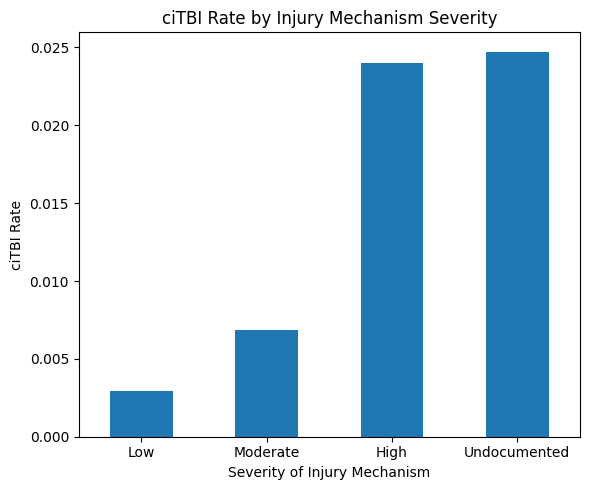

In [195]:
plt.figure(figsize=(6,5))

severity_rate = clean_df.groupby("High_impact_InjSev")["PosIntFinal"].mean()

severity_rate.plot(kind="bar")
plt.xticks([0,1,2, 3], ["Low", "Moderate", "High", "Undocumented"], rotation=0)
plt.xlabel("Severity of Injury Mechanism")
plt.ylabel("ciTBI Rate")
plt.title("ciTBI Rate by Injury Mechanism Severity")
plt.tight_layout()
plt.show()

## Reality Check

In [6]:
citbi_rate = clean_df["PosIntFinal"].mean()

ct_rate = (clean_df["CTDone"] == 1).mean()

print(f"Overall ciTBI rate: {citbi_rate:.4f} ({citbi_rate*100:.2f}%)")
print(f"CT utilization rate: {ct_rate:.4f} ({ct_rate*100:.2f}%)")

Overall ciTBI rate: 0.0089 (0.89%)
CT utilization rate: 0.3529 (35.29%)


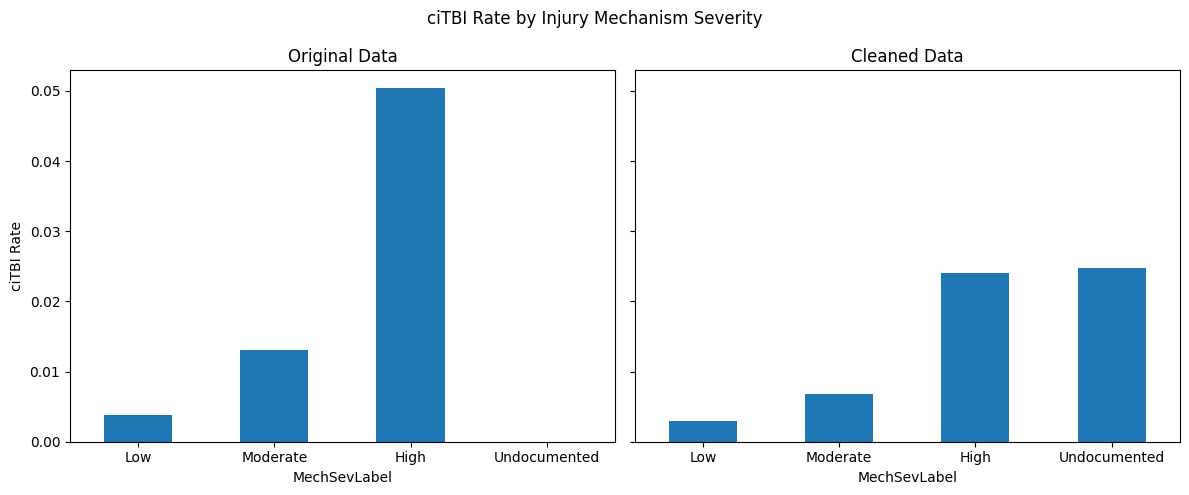

In [11]:
severity_map = {1:"Low", 2:"Moderate", 3:"High", 4:"Undocumented"}

#Cleaned data
tmp_clean = clean_df.copy()
tmp_clean["MechSevLabel"] = tmp_clean["High_impact_InjSev"].map(severity_map)

rate_clean = (
    tmp_clean.groupby("MechSevLabel")["PosIntFinal"]
    .mean()
    .reindex(["Low","Moderate","High","Undocumented"])
)

#Original data
tmp_orig = original_data.copy()
tmp_orig["MechSevLabel"] = tmp_orig["High_impact_InjSev"].map(severity_map)

rate_orig = (
    tmp_orig.groupby("MechSevLabel")["PosIntFinal"]
    .mean()
    .reindex(["Low","Moderate","High","Undocumented"])
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

rate_orig.plot(kind="bar", ax=axes[0])
axes[0].set_title("Original Data")
axes[0].set_ylabel("ciTBI Rate")
axes[0].tick_params(axis='x', rotation=0)

rate_clean.plot(kind="bar", ax=axes[1])
axes[1].set_title("Cleaned Data")
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle("ciTBI Rate by Injury Mechanism Severity")
plt.tight_layout()
plt.show()

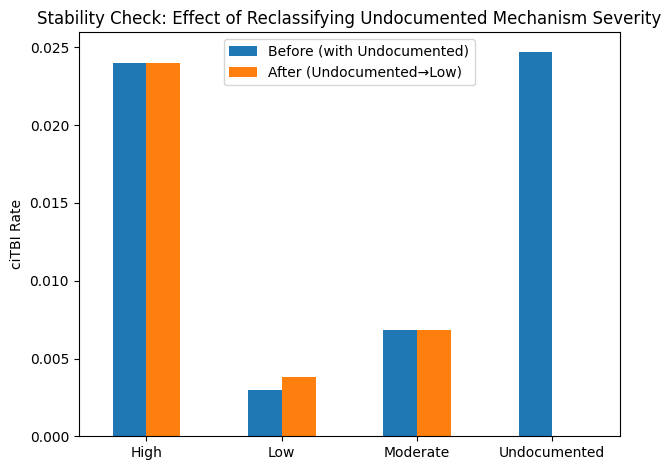

In [12]:

before = tmp_clean.groupby("MechSevLabel")["PosIntFinal"].mean().reindex(
    ["Low","Moderate","High","Undocumented"]
)

perturbed = clean_df.copy()
perturbed["High_impact_InjSev_perturbed"] = perturbed["High_impact_InjSev"].replace({4: 1})
perturbed["MechSevLabel_perturbed"] = perturbed["High_impact_InjSev_perturbed"].map({1:"Low", 2:"Moderate", 3:"High"})

after = perturbed.groupby("MechSevLabel_perturbed")["PosIntFinal"].mean().reindex(
    ["Low","Moderate","High"]
)

compare = pd.DataFrame({
    "Before (with Undocumented)": before.dropna(),
    "After (Undocumented→Low)": after
})

compare.plot(kind="bar")
plt.ylabel("ciTBI Rate")
plt.title("Stability Check: Effect of Reclassifying Undocumented Mechanism Severity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# MODELING

### Modeling on Clean DataSet

/opt/anaconda3/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



PECARN-Style Rule
  Accuracy : 0.7567
  Precision: 0.6240
  Recall   : 0.7818
  Confusion Matrix [tn fp; fn tp]: [6117 2116; 980 3511]

Logistic Regression (thr=0.5)
  Accuracy : 0.7795
  Precision: 0.7642
  Recall   : 0.5426
  AUC      : 0.8279
  Confusion Matrix [tn fp; fn tp]: [7481 752; 2054 2437]

Random Forest (thr=0.5)
  Accuracy : 0.8128
  Precision: 0.7835
  Recall   : 0.6489
  AUC      : 0.8668
  Confusion Matrix [tn fp; fn tp]: [7428 805; 1577 2914]
Saved ROC plot to: outputs/model_accuracy.png
Saved ROC plot to: outputs/rf_feature_importance.png


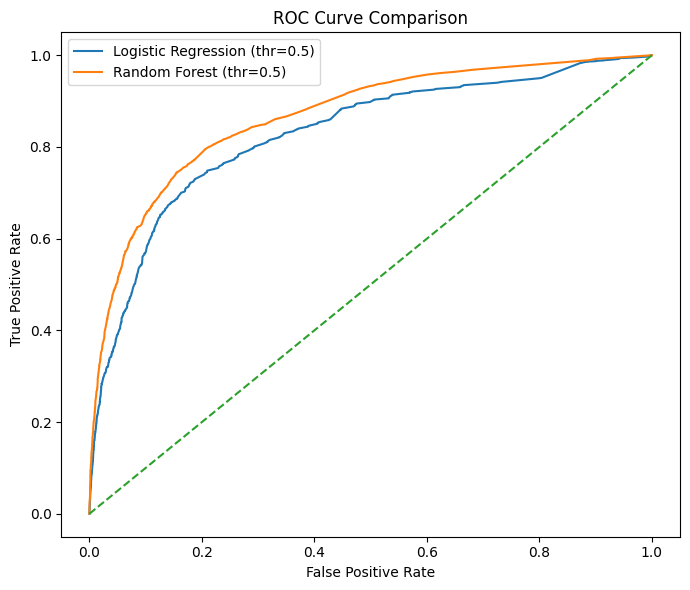

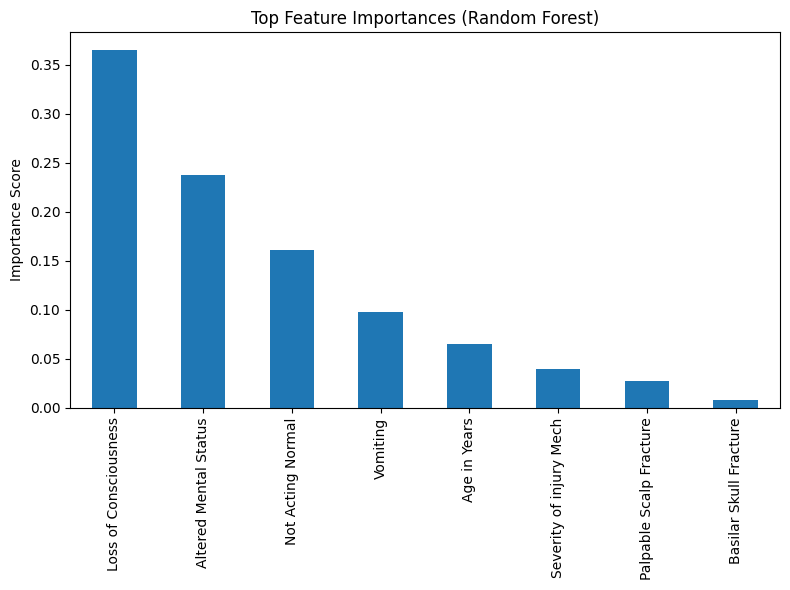

In [17]:
%run models.py

## Modeling on perturbed data

/opt/anaconda3/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



PECARN-Style Rule
  Accuracy : 0.7567
  Precision: 0.6240
  Recall   : 0.7818
  Confusion Matrix [tn fp; fn tp]: [6117 2116; 980 3511]

Logistic Regression (thr=0.5)
  Accuracy : 0.7789
  Precision: 0.7590
  Recall   : 0.5475
  AUC      : 0.8281
  Confusion Matrix [tn fp; fn tp]: [7452 781; 2032 2459]

Random Forest (thr=0.5)
  Accuracy : 0.8106
  Precision: 0.7906
  Recall   : 0.6304
  AUC      : 0.8670
  Confusion Matrix [tn fp; fn tp]: [7483 750; 1660 2831]
Saved ROC plot to: outputs/model_accuracy.png
Saved ROC plot to: outputs/rf_feature_importance.png


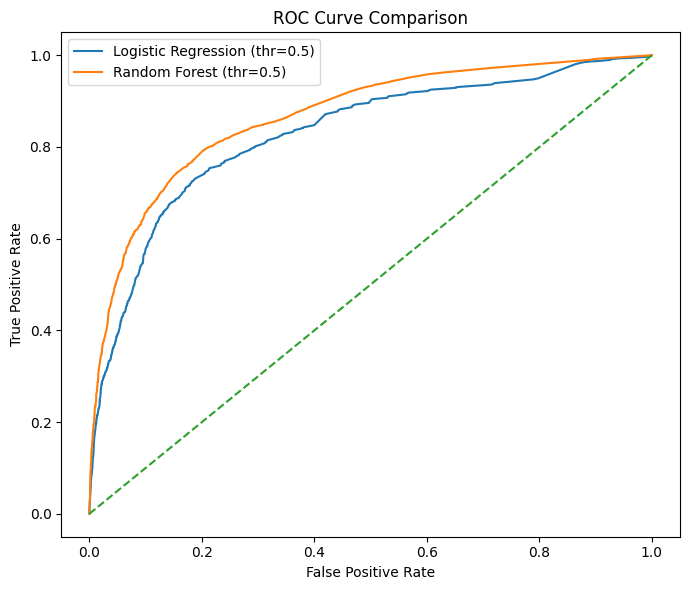

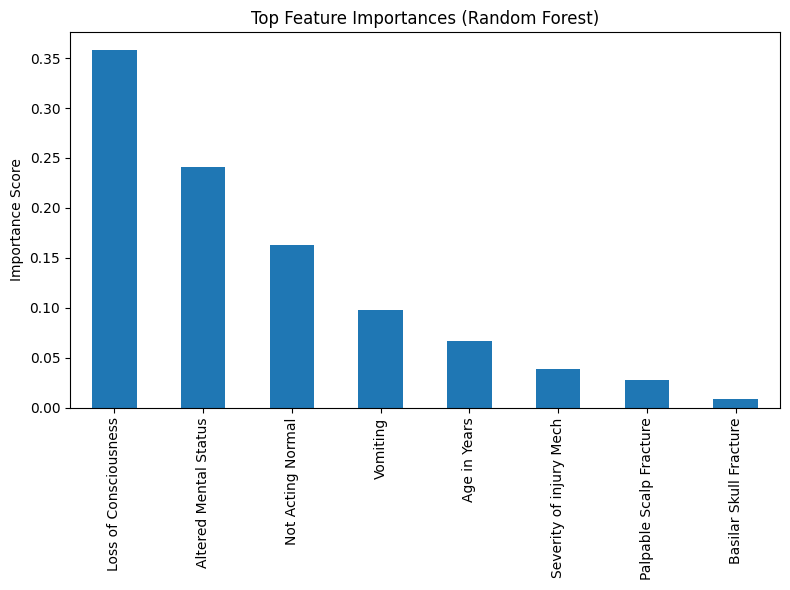

In [18]:
%run models.py perturb